# 🧾 Northwind Sales & Orders Analysis

An EDA on 830 orders (2,161 order-product lines) from the classic Northwind sales
database: who buys, from where, how much, and why trusting a textbook outlier rule
on revenue data would have quietly deleted a third of the company's sales.

**Dataset:** `all_data.csv` — a flat export joining Northwind's Customers, Orders,
Order Details, Products and Suppliers tables, 2,161 rows × 22 columns.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path

# --- brand theme -------------------------------------------------------
BG, FG, GRID = "#010A19", "#EEF2F7", "#33405C"
TEAL, PURPLE, CORAL, AMBER = "#60F5D2", "#D6B2FC", "#FF7A90", "#F6E27F"
BLUE = "#7AA2FF"

sns.set_theme(style="dark", context="notebook", rc={
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": FG, "axes.titlecolor": FG,
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.7,
    "text.color": FG, "xtick.color": FG, "ytick.color": FG,
    "legend.facecolor": BG, "legend.edgecolor": GRID, "legend.labelcolor": FG,
})
sns.set_palette([TEAL, PURPLE, AMBER, CORAL, BLUE])

BRAND_DIVERGING = LinearSegmentedColormap.from_list("brand_diverging", [CORAL, "#0B1730", TEAL])

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(IMAGES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

def money(x, pos=None):
    return f"${x:,.0f}"

pd.options.display.float_format = "{:.2f}".format
pd.options.display.max_columns = None

## 2. Load & Inspect

The raw export joins five Northwind tables into one flat file: a customer, their
order, every product line on that order, and that product's supplier — so a
multi-product order appears as multiple rows sharing the same `OrderID`.

In [2]:
DATA_PATH = Path("data/all_data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Expected the dataset at {DATA_PATH.resolve()}. "
        "Run this notebook from the repository root (see README)."
    )

df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
df.head(3)

shape: (2161, 22)


,CustomerID,FirstName,LastName,City,Country,Phone,OrderID,OrderDate,OrderNumber,TotalAmount,ProductID,ProductName,UnitPrice,Package,IsDiscontinued,SupplierID,CompanyName,ContactName,City.1,Country.1,Phone.1,Fax
0,85.00,Paul,Henriot,Reims,France,26.47.15.10,1.00,7/4/2012 0:00,542378.00,440.00,11.00,Queso Cabrales,21.00,1 kg pkg.,False,5.00,Cooperativa de Quesos 'Las Cabras',Antonio del Valle Saavedra,Oviedo,Spain,(98) 598 76 54,NaN
1,85.00,Paul,Henriot,Reims,France,26.47.15.10,1.00,7/4/2012 0:00,542378.00,440.00,42.00,Singaporean Hokkien Fried Mee,14.00,32 - 1 kg pkgs.,True,20.00,Leka Trading,Chandra Leka,Singapore,Singapore,555-8787,NaN
2,85.00,Paul,Henriot,Reims,France,26.47.15.10,1.00,7/4/2012 0:00,542378.00,440.00,72.00,Mozzarella di Giovanni,34.80,24 - 200 g pkgs.,False,14.00,Formaggi Fortini s.r.l.,Elio Rossi,Ravenna,Italy,(0544) 60323,(0544) 60603


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2161 entries, 0 to 2160
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      2158 non-null   float64
 1   FirstName       2158 non-null   str    
 2   LastName        2158 non-null   str    
 3   City            2158 non-null   str    
 4   Country         2158 non-null   str    
 5   Phone           2158 non-null   str    
 6   OrderID         2155 non-null   float64
 7   OrderDate       2155 non-null   str    
 8   OrderNumber     2155 non-null   float64
 9   TotalAmount     2155 non-null   float64
 10  ProductID       2157 non-null   float64
 11  ProductName     2157 non-null   str    
 12  UnitPrice       2157 non-null   float64
 13  Package         2157 non-null   str    
 14  IsDiscontinued  2157 non-null   object 
 15  SupplierID      2157 non-null   float64
 16  CompanyName     2157 non-null   str    
 17  ContactName     2157 non-null   str    
 18 

`City`, `Country` and `Phone` each appear **twice** — once for the customer
(cols 4-6) and once for the supplier (cols 19-21) — so pandas auto-suffixed the
second occurrence of each with `.1`. That gets resolved in Section 4.

In [4]:
df.isna().sum()

CustomerID           3
FirstName            3
LastName             3
City                 3
Country              3
Phone                3
OrderID              6
OrderDate            6
OrderNumber          6
TotalAmount          6
ProductID            4
ProductName          4
UnitPrice            4
Package              4
IsDiscontinued       4
SupplierID           4
CompanyName          4
ContactName          4
City.1               4
Country.1            4
Phone.1              4
Fax               1214
dtype: int64

## 3. Data Quality Assessment

### 3.1 Six trailing blank rows

In [5]:
blank_rows = df[df["OrderID"].isna()]
print(f"Rows with no OrderID: {len(blank_rows)}")
blank_rows[["CustomerID", "OrderID", "ProductID", "SupplierID"]]

Rows with no OrderID: 6


,CustomerID,OrderID,ProductID,SupplierID
2155,NaN,NaN,78.00,22.00
2156,NaN,NaN,79.00,NaN
2157,92.00,NaN,NaN,NaN
2158,22.00,NaN,NaN,NaN
2159,57.00,NaN,NaN,NaN
2160,NaN,NaN,NaN,30.00


⚠️ **Finding:** the last six rows of the file (indices 2155-2160) are trailing
export artifacts — every one is missing `OrderID`, and four of them are missing
almost everything else too (`ProductID`, `SupplierID`, `CompanyName`...). They
aren't scattered missing data, just blank rows tacked onto the end of the export.
Dropping rows with no `OrderID` removes exactly these six and nothing else.

### 3.2 Duplicate column names (customer vs. supplier)

In [6]:
df = df.dropna(subset=["OrderID"]).reset_index(drop=True)
df = df.rename(columns={"City.1": "SuppCity", "Country.1": "SuppCountry", "Phone.1": "SuppPhone"})
print("Resolved columns:", [c for c in df.columns if c.startswith("Supp")])

Resolved columns: ['SupplierID', 'SuppCity', 'SuppCountry', 'SuppPhone']


### 3.3 One row per order × product — safe to collapse to order level?

This analysis looks at **orders**, not individual product lines, so multi-product
orders need to become a single row each. That's only safe if every column kept in
the order-level view is genuinely constant across an order's product lines —
otherwise collapsing would silently pick one arbitrary value and discard the rest.

In [7]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
for c in df.columns:
    if "ID" in c or c == "OrderNumber":
        df[c] = df[c].astype(int)

rows_per_order = df.groupby("OrderID").size()
print("rows per order:\n", rows_per_order.value_counts().sort_index())
print()
print("largest order: OrderID", rows_per_order.idxmax(), "with", rows_per_order.max(), "product lines")
print()

order_level_cols = ["CustomerID", "FirstName", "LastName", "City", "Country", "OrderDate", "TotalAmount"]
varies = {c: (df.groupby("OrderID")[c].nunique() > 1).sum() for c in order_level_cols}
print("orders where this column is NOT constant across its product lines:")
for c, n in varies.items():
    print(f"  {c}: {n} of {df['OrderID'].nunique()} orders")

rows per order:
 1     137
2     283
3     248
4     125
5      33
6       3
25      1
Name: count, dtype: int64

largest order: OrderID 830 with 25 product lines

orders where this column is NOT constant across its product lines:
  CustomerID: 0 of 830 orders
  FirstName: 0 of 830 orders
  LastName: 0 of 830 orders
  City: 0 of 830 orders
  Country: 0 of 830 orders
  OrderDate: 0 of 830 orders
  TotalAmount: 0 of 830 orders


✅ **Verified safe:** `TotalAmount` and every customer-level column
(`CustomerID`, name, city, country, order date) are identical across **all** of an
order's product-line rows, for all 830 orders — confirmed above (0 orders vary).
`TotalAmount` is the order's total, repeated on each line, not a per-product
amount. That means keeping the first row per `OrderID` loses no information for an
order-level analysis — it only discards the repeated product-line rows, which is
exactly what the original notebook's `drop_duplicates(subset="OrderID")` already
did correctly.

### 3.4 Unrecoverable "mojibake" in names, cities and products

In [8]:
def mojibake_report(frame, cols):
    rows = []
    for c in cols:
        mask = frame[c].astype(str).str.contains(r"\?", na=False, regex=True)
        if mask.any():
            rows.append((c, int(mask.sum()), frame.loc[mask, c].unique()[:4]))
    return rows

report = mojibake_report(df, ["FirstName", "LastName", "City", "ProductName", "CompanyName", "ContactName"])
for col, n, examples in report:
    print(f"{col}: {n} rows affected, e.g. {list(examples)}")

FirstName: 46 rows affected, e.g. ['Mart?n', 'L?cia']
LastName: 93 rows affected, e.g. ['Hern?ndez', 'Gonz?lez', 'Fern?ndez']
City: 202 rows affected, e.g. ['San Crist?bal', 'K?ln', 'Br?cke', 'Lule?']
ProductName: 335 rows affected, e.g. ["Gustaf's Kn?ckebr?d", 'Guaran? Fant?stica', 'Original Frankfurter grüne So?e', 'Lakkalik??ri']
CompanyName: 323 rows affected, e.g. ['PB Kn?ckebr?d AB', 'Svensk Sj?f?da AB', 'Plutzer Lebensmittelgro?m?rkte AG', 'Heli Sü?waren GmbH & Co. KG']
ContactName: 51 rows affected, e.g. ['Michael Bj?rn']


In [9]:
with open(DATA_PATH, "rb") as f:
    raw = f.read()
sample_pos = raw.find(b"So?e")
print("raw bytes around one example:", raw[sample_pos - 5: sample_pos + 6])
print("the '?' is a literal ASCII byte:", raw[sample_pos + 2: sample_pos + 3] == b"?")

raw bytes around one example: b'\xc3\xbcne So?e,1'
the '?' is a literal ASCII byte: True


⚠️ **Finding:** 11 product names, 5 cities and several customer/company names
contain a **literal `?` character** — e.g. `Rh?nbr?u Klosterbier` (should read
*Rhönbräu Klosterbier*), `Hern?ndez` (*Hernández*), `K?ln` (*Köln*). Checking the
raw bytes confirms the `?` is literally ASCII `0x3F`, not a decoding mistake made
in this notebook — it was already baked into the source file by a lossy encoding
conversion earlier in the data's history (ö/ä/ü/ß/å/é turned into `?` and the
original characters are gone). No encoding choice here can recover them, so this
is documented as a known limitation (Section 10) rather than silently guessed at
or left for a reader to discover on their own.

## 4. Clean & Prepare

In [10]:
df = df.drop_duplicates(subset="OrderID").reset_index(drop=True)

orders = df[["CustomerID", "FirstName", "LastName", "City", "Country",
             "OrderID", "OrderNumber", "OrderDate", "TotalAmount"]].copy()
orders["FullName"] = orders["FirstName"] + " " + orders["LastName"]

print("orders shape:", orders.shape)
print("date range:", orders['OrderDate'].min().date(), "to", orders['OrderDate'].max().date())
print("unique customers:", orders['CustomerID'].nunique(), "| unique countries:", orders['Country'].nunique())
orders.head(3)

orders shape: (830, 10)
date range: 2012-07-04 to 2014-05-06
unique customers: 89 | unique countries: 21


,CustomerID,FirstName,LastName,City,Country,OrderID,OrderNumber,OrderDate,TotalAmount,FullName
0,85,Paul,Henriot,Reims,France,1,542378,2012-07-04,440.00,Paul Henriot
1,79,Karin,Josephs,Münster,Germany,2,542379,2012-07-05,1863.40,Karin Josephs
2,34,Mario,Pontes,Rio de Janeiro,Brazil,3,542380,2012-07-08,1813.00,Mario Pontes


## 5. Outlier Handling: Why a Textbook IQR Rule Would Have Been a Mistake

The original notebook computed IQR outlier bounds on `TotalAmount` — then ignored
them and used an unexplained, hardcoded cutoff of \$15,000 instead, which only
removed the 3 most extreme orders. What would actually happen if the IQR bounds it
computed had been *applied*?

In [11]:
q1, q2, q3 = orders["TotalAmount"].quantile([0.25, 0.5, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

print(f"Q1 = ${q1:,.2f}   Q2 (median) = ${q2:,.2f}   Q3 = ${q3:,.2f}")
print(f"IQR = ${iqr:,.2f}")
print(f"Upper fence (Q3 + 1.5*IQR) = ${upper_bound:,.2f}")
print()
print(f"Original notebook's cutoff: $15,000 -> removes "
      f"{(orders['TotalAmount'] > 15000).sum()} orders")
print(f"Textbook IQR fence:         ${upper_bound:,.0f} -> flags "
      f"{(orders['TotalAmount'] > upper_bound).sum()} orders")

Q1 = $480.00   Q2 (median) = $1,015.90   Q3 = $2,028.65
IQR = $1,548.65
Upper fence (Q3 + 1.5*IQR) = $4,351.62

Original notebook's cutoff: $15,000 -> removes 3 orders
Textbook IQR fence:         $4,352 -> flags 56 orders


In [12]:
flagged = orders["TotalAmount"] > upper_bound
n_flagged = flagged.sum()
pct_orders = n_flagged / len(orders) * 100
revenue_flagged = orders.loc[flagged, "TotalAmount"].sum()
pct_revenue = revenue_flagged / orders["TotalAmount"].sum() * 100

print(f"Orders beyond the IQR fence: {n_flagged} ({pct_orders:.1f}% of all orders)")
print(f"Revenue in those orders:    ${revenue_flagged:,.2f} ({pct_revenue:.1f}% of total revenue)")
print(f"Total revenue, all orders:  ${orders['TotalAmount'].sum():,.2f}")

Orders beyond the IQR fence: 56 (6.7% of all orders)
Revenue in those orders:    $412,992.47 (30.5% of total revenue)
Total revenue, all orders:  $1,354,458.59


⚠️ **Finding:** orders beyond the IQR fence are only **6.7%** of all orders by
count — but they hold **30.5% of total revenue**. None of them contain impossible
or corrupted values (no negative amounts, `TotalAmount` verified constant per
order in Section 3.3) — they're genuinely large wholesale orders from real repeat
customers (Section 7 names several). Applying the IQR rule as a deletion filter,
the way many tutorials teach it, would have silently erased nearly a third of the
company's revenue from every chart and total in this notebook.

**The fix:** the IQR fence is used below only to *describe* the shape of the
distribution (it's heavily right-skewed, which is normal for order revenue — most
orders are modest, a few are large), never to drop rows. No revenue or order-count
figure anywhere in this notebook excludes these orders.

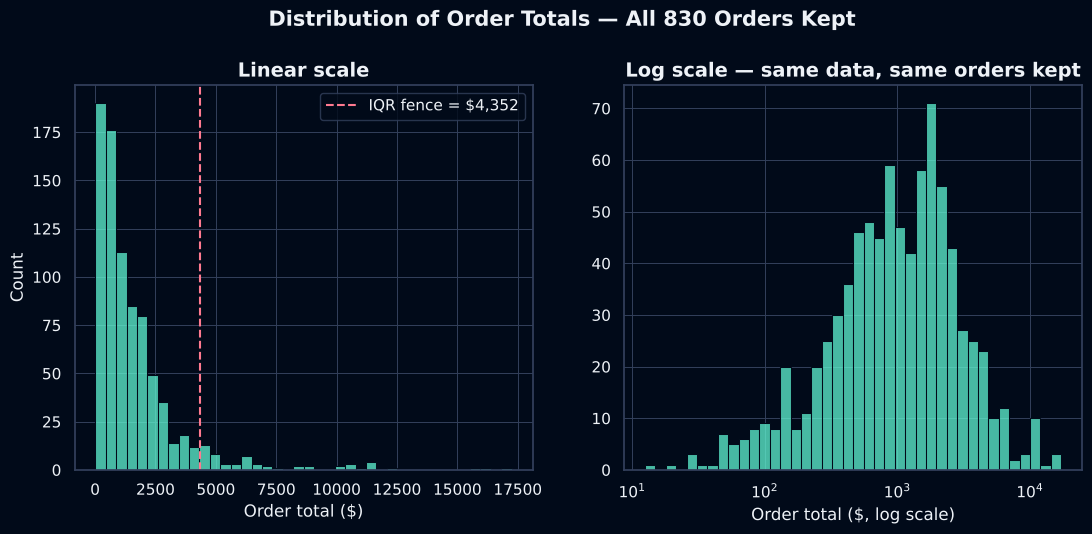

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(orders["TotalAmount"], bins=40, color=TEAL, edgecolor=BG, ax=axes[0])
axes[0].axvline(upper_bound, color=CORAL, linestyle="--", linewidth=1.5,
                label=f"IQR fence = ${upper_bound:,.0f}")
axes[0].set_title("Linear scale")
axes[0].set_xlabel("Order total ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

sns.histplot(orders["TotalAmount"], bins=40, color=TEAL, edgecolor=BG, ax=axes[1], log_scale=True)
axes[1].set_title("Log scale — same data, same orders kept")
axes[1].set_xlabel("Order total ($, log scale)")
axes[1].set_ylabel("")

fig.suptitle("Distribution of Order Totals — All 830 Orders Kept", fontsize=15, fontweight="bold", y=1.03)
save_fig(fig, "01_order_totals_distribution")
plt.show()

The log-scale view on the right shows the same 830 orders look far more
symmetric on a log axis — a sign the "long tail" on the left is the ordinary shape
of revenue data, not a sign of errors needing removal.

## 6. Univariate Analysis

In [14]:
orders["TotalAmount"].describe().round(2)

count     830.00
mean     1631.88
std      1990.61
min        12.50
25%       480.00
50%      1015.90
75%      2028.65
max     17250.00
Name: TotalAmount, dtype: float64

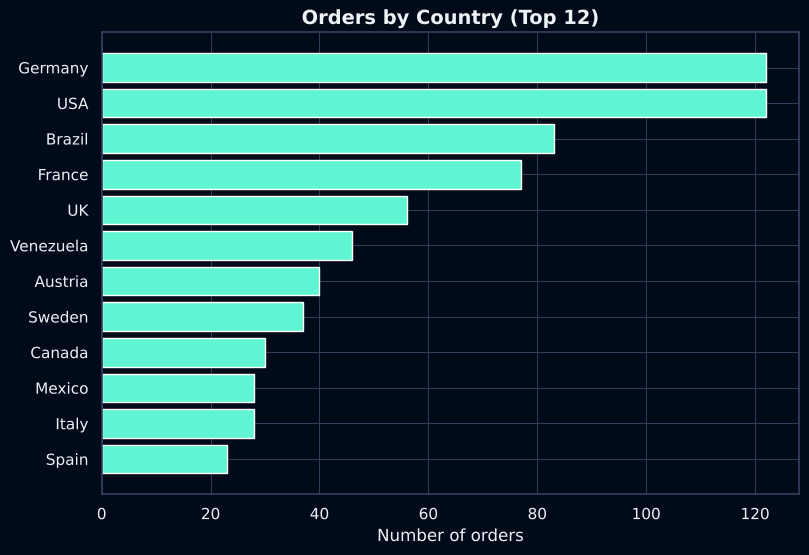

In [15]:
top_countries = orders["Country"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=TEAL)
ax.set_title("Orders by Country (Top 12)")
ax.set_xlabel("Number of orders")
save_fig(fig, "02_orders_by_country")
plt.show()

Germany and the USA each place **122** orders, the most of any country,
followed by Brazil, France and the UK — a reasonably broad spread across
21 countries rather than dependence on one or two markets.

## 7. Bivariate Analysis

### Revenue by country

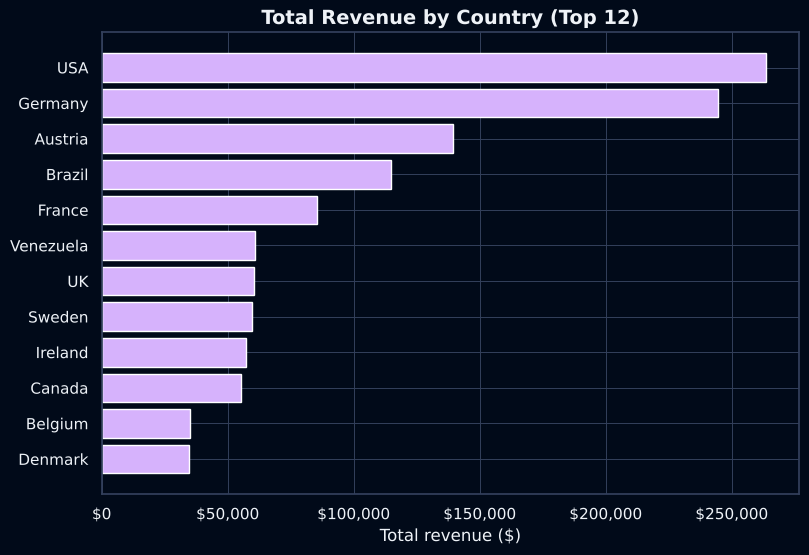

In [16]:
rev_by_country = (orders.groupby("Country")["TotalAmount"]
                   .sum().sort_values(ascending=False))
top_rev_countries = rev_by_country.head(12)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_rev_countries.index[::-1], top_rev_countries.values[::-1], color=PURPLE)
ax.set_title("Total Revenue by Country (Top 12)")
ax.set_xlabel("Total revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
save_fig(fig, "03_revenue_by_country")
plt.show()

Germany and the USA lead on order *count*, but **the USA, Germany and
Austria lead on revenue** — Austria places far fewer orders than Brazil or France
yet out-earns both, meaning its orders run larger on average.

### Top customers

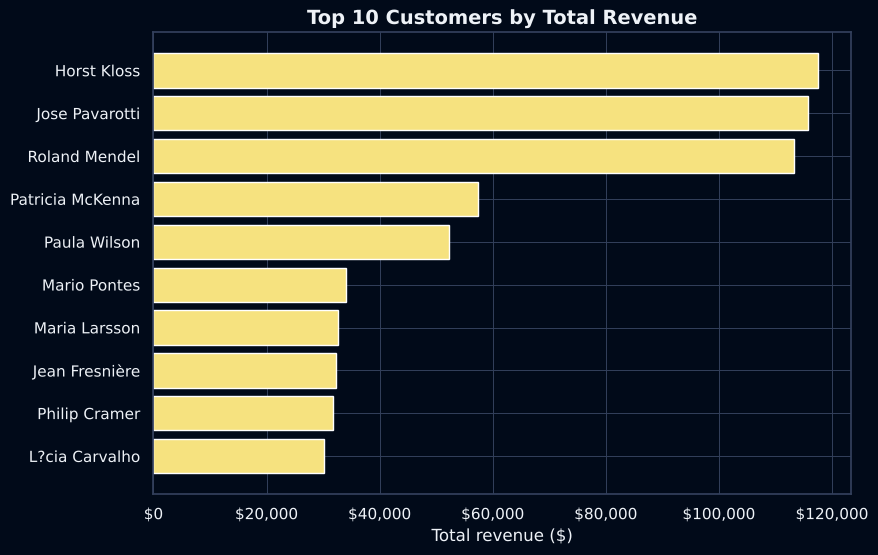

In [17]:
top_customers_rev = (orders.groupby("FullName")["TotalAmount"]
                      .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_customers_rev.index[::-1], top_customers_rev.values[::-1], color=AMBER)
ax.set_title("Top 10 Customers by Total Revenue")
ax.set_xlabel("Total revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
save_fig(fig, "04_top_customers")
plt.show()

The top three customers (Horst Kloss, Jose Pavarotti, Roland Mendel) each
generated over \$113,000 — together more than 25% of all 10 top-customer revenue
shown here comes from just those three relationships. Several of these are exactly
the large, legitimate orders that Section 5 shows a blind IQR filter would have
deleted.

## 8. Trends Over Time

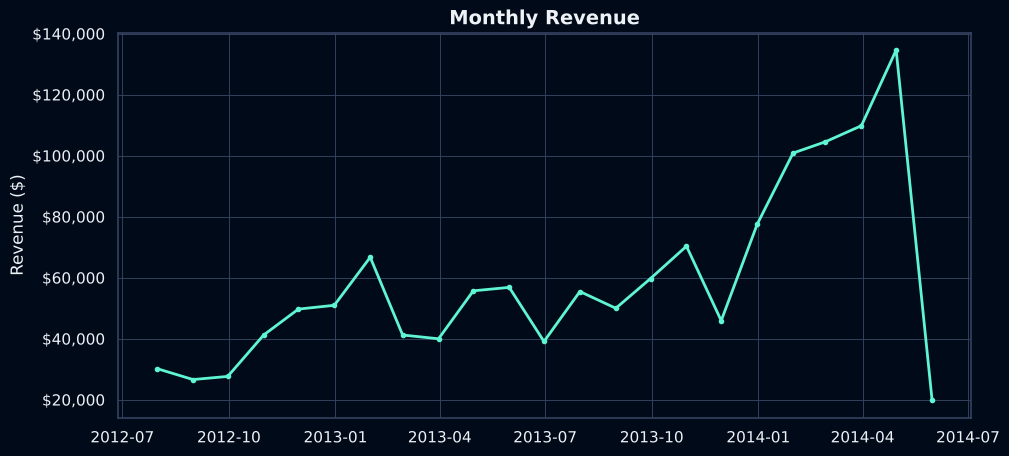

In [18]:
monthly = (orders.set_index("OrderDate")
           .resample("ME")["TotalAmount"]
           .agg(["sum", "count"])
           .rename(columns={"sum": "revenue", "count": "orders"}))

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(monthly.index, monthly["revenue"], color=TEAL, linewidth=2, marker="o", markersize=3)
ax1.set_title("Monthly Revenue")
ax1.set_ylabel("Revenue ($)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(money))
save_fig(fig, "05_monthly_revenue")
plt.show()

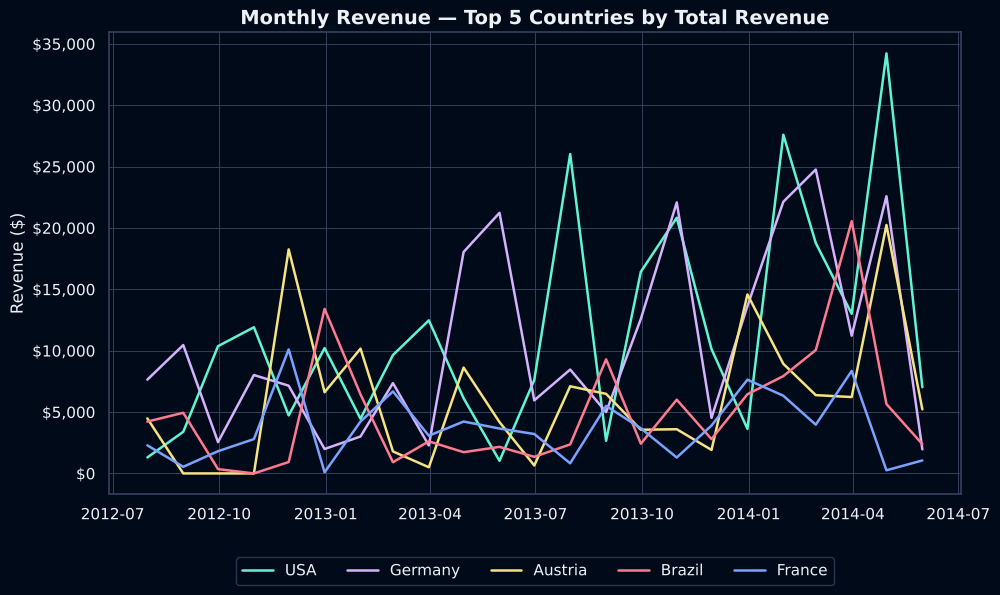

In [19]:
top5 = rev_by_country.head(5).index.tolist()
monthly_country = (orders[orders["Country"].isin(top5)]
                    .set_index("OrderDate")
                    .groupby("Country")
                    .resample("ME")["TotalAmount"].sum()
                    .unstack("Country"))

fig, ax = plt.subplots(figsize=(11, 6))
for country, color in zip(top5, [TEAL, PURPLE, AMBER, CORAL, BLUE]):
    ax.plot(monthly_country.index, monthly_country[country], label=country,
            color=color, linewidth=1.8)
ax.set_title("Monthly Revenue — Top 5 Countries by Total Revenue")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12))
save_fig(fig, "06_monthly_revenue_by_country")
plt.show()

Monthly revenue is noisy month to month — expected with only 830 orders
spread across 21 countries and ~23 months — but no country shows a sustained
decline, and the spikes line up with the large individual orders identified in
Sections 5 and 7 rather than any seasonal pattern. Total monthly revenue trends
upward overall, from roughly \$30K/month in mid-2012 to over \$100K/month by
early 2014. **Note:** the data ends 2014-05-06, so the final point on each chart
is a partial month, not a real year-over-year drop — worth excluding or
annotating if this notebook is extended.

## 9. Conclusions & Key Insights

1. **A textbook IQR outlier rule would have deleted 30.5% of total revenue.**
   Orders beyond the statistical fence are only 6.7% of orders by count (56 of
   830) but hold \$412,992 of the company's \$1,354,459 in total revenue. None
   show evidence of being data errors — they're real, large orders from repeat
   customers. The original notebook's unexplained \$15,000 cutoff only removed 3
   orders; a "more rigorous-looking" strict IQR cutoff would have been far worse,
   not better. The lesson generalizes: an outlier rule built for roughly
   symmetric, error-prone measurements (like the altitude values in a companion
   project) is the wrong tool for naturally right-skewed, legitimate business
   data — statistical outlier $\\neq$ data error.
2. **Collapsing multi-product orders to one row per order is safe here, and it was
   verified, not assumed.** `TotalAmount` and every customer-level field are
   identical across all of an order's product lines for all 830 orders — checked
   explicitly in Section 3.3, not taken on faith.
3. **Six trailing blank rows, not scattered missing data.** Every row missing
   `OrderID` sits at the very end of the file and is missing most of its other
   fields too — an export artifact, cleanly removed by one condition.
4. **Some names, cities and products carry unrecoverable `?` characters** from a
   lossy encoding conversion earlier in the data's history (e.g. *Rhönbräu
   Klosterbier* → `Rh?nbr?u Klosterbier`). This can't be fixed from this file
   alone and is documented rather than silently guessed at.
5. **The USA, Germany and Austria are the top three markets by revenue**, with
   Austria notable for high revenue from relatively few orders — its average
   order size outpaces higher-order-count countries like Brazil and France.

**Next steps:** bring in the `UnitPrice`/`Package` product-level columns (unused
here, since this notebook stays at order level) to see whether Austria's high
average order size is concentrated in a few expensive products or spread evenly;
model monthly revenue with a trend/seasonality decomposition now that almost two
full years of data are available.

## Environment

In [20]:
import sys, matplotlib
print("python    ", sys.version.split()[0])
print("pandas    ", pd.__version__)
print("numpy     ", np.__version__)
print("matplotlib", matplotlib.__version__)
print("seaborn   ", sns.__version__)

python     3.13.16
pandas     3.0.5
numpy      2.5.3
matplotlib 3.11.2
seaborn    0.13.2
